In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import math
import random
import matplotlib.pyplot as plt
import numpy as np

# Functions


## Activation Functions

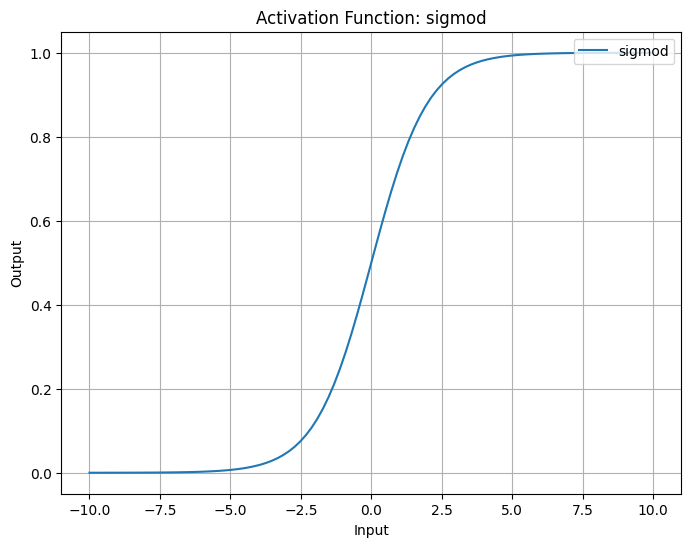

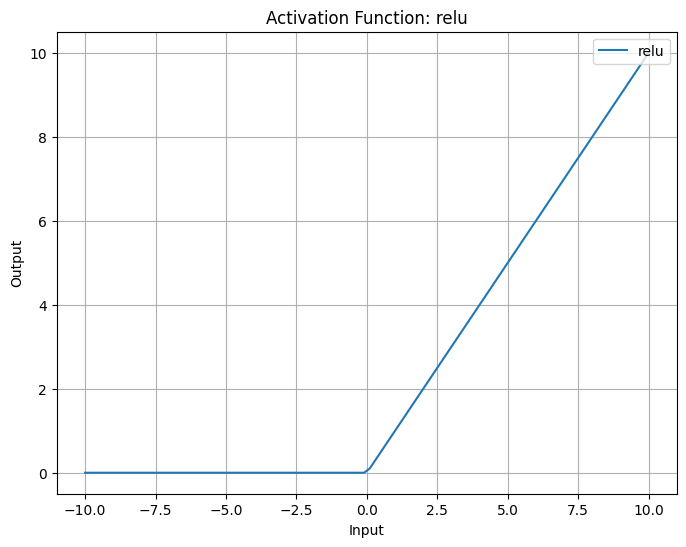

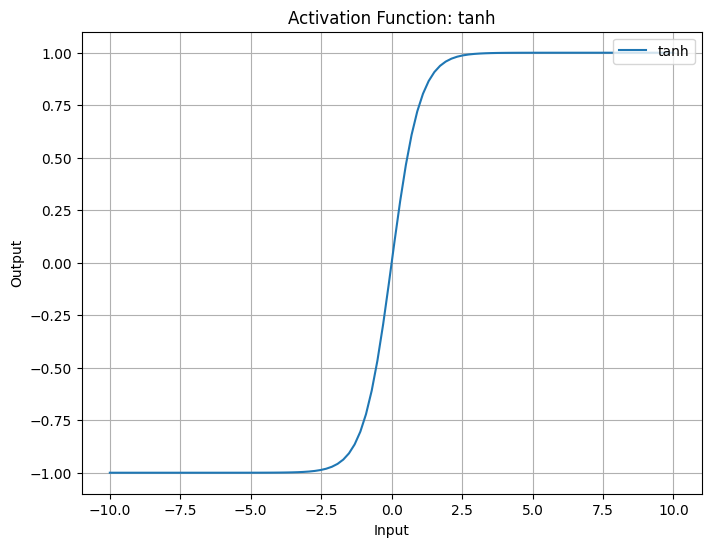

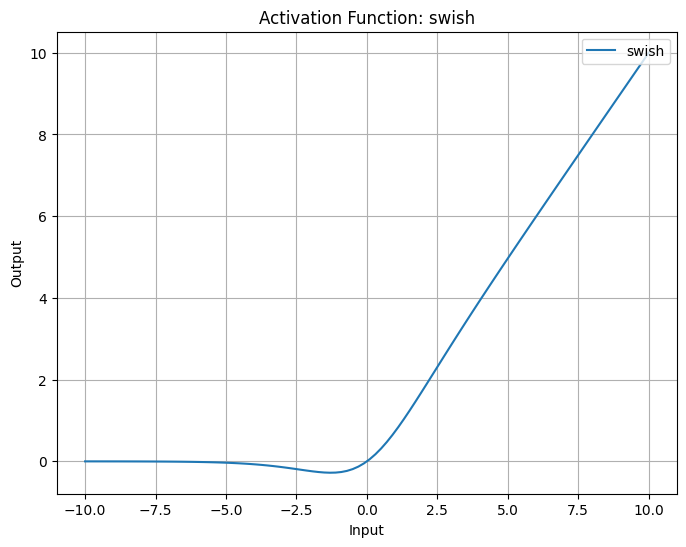

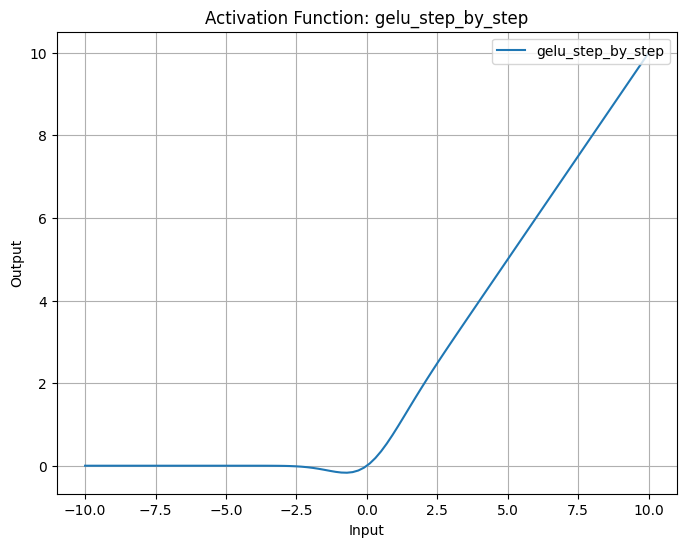

In [3]:
def sigmod(x: torch.Tensor) -> torch.Tensor:
    return 1/(1 + torch.exp(-x))

def relu(x: torch.Tensor) -> torch.Tensor:
    return torch.maximum(torch.zeros_like(x), x)

def leaky_relu(x: torch.Tensor, negative_slope=0.01) -> torch.Tensor:
    return torch.where(x > 0, x, x * negative_slope)

def tanh(x: torch.Tensor) -> torch.Tensor:
    return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

def swish(x: torch.Tensor) -> torch.Tensor:
    return x * sigmod(x)

def gelu_step_by_step(x: torch.Tensor) -> torch.Tensor:
    """逐步计算 GELU，便于理解"""
    # 常数
    sqrt_2_over_pi = torch.sqrt(torch.tensor(2.0 / torch.pi))
    
    # 计算三次项
    cubic = 0.044715 * x ** 3
    
    # 计算双曲正切参数
    tanh_input = sqrt_2_over_pi * (x + cubic)
    
    # 计算 tanh
    tanh_val = torch.tanh(tanh_input)
    
    # 最终结果
    result = 0.5 * x * (1 + tanh_val)
    
    return result


def draw_pic_for_activation(func, x_range=(-10, 10), num_points=100):
    x = np.linspace(x_range[0], x_range[1], num_points)
    x_tensor = torch.tensor(x, dtype=torch.float32)
    y_tensor = func(x_tensor)
    y = y_tensor.numpy()
    
    figure = plt.figure(figsize=(8, 6))
    plt.plot(x, y, label=func.__name__)
    plt.title(f'Activation Function: {func.__name__}')
    plt.xlabel('Input')
    plt.ylabel('Output')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.show()

for activation_func in [sigmod, relu, tanh, swish, gelu_step_by_step]:
    draw_pic_for_activation(activation_func)



## Loss func

In [ ]:
def MSELoss(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
    return torch.mean((y_true - y_pred) ** 2)

def CrossEntropyLossBinary(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
    y_pred = torch.clamp(y_pred, 1e-15, 1 - 1e-15)  # 防止 log(0)
    return -torch.mean(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))

def CrossEntropyLossMultiClass(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
    y_pred = torch.clamp(y_pred, 1e-15, 1 - 1e-15)  # 防止 log(0)
    return -torch.mean(torch.sum(y_true * torch.log(y_pred), dim=1))



## Distribution Functions

In [ ]:
import torch
from torch.distributions import (
    Normal, MultivariateNormal, Bernoulli, Categorical, Uniform
)

# 1. 单&多维高斯分布（2维，协方差矩阵为单位矩阵）
x = torch.tensor([1.0, 2.0, 3.0])
mu = torch.tensor([0.0])
sigma = torch.tensor([1.0])

# 手写实现结果
handwritten = -0.5 * ((x - mu) / sigma) ** 2 - torch.log(sigma) - 0.5 * torch.log(torch.tensor(2 * torch.pi))
# PyTorch 内置实现结果
torch_builtin = Normal(mu, sigma).log_prob(x)

mu = torch.tensor([0.0, 0.0])
cov = torch.eye(2)
multi_norm = MultivariateNormal(loc=mu, covariance_matrix=cov)
x = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
print(multi_norm.log_prob(x))  # 输出2个样本的log pdf

# 2. 伯努利分布（二分类，logits=预测分数）
logits = torch.tensor([0.5, -1.0, 2.0])
bernoulli = Bernoulli(logits=logits)
y = torch.tensor([1, 0, 1])
print(bernoulli.log_prob(y))  # 输出每个标签的log似然

# 3. 类别分布（3分类，probs=类别概率）
probs = torch.tensor([[0.2, 0.5, 0.3], [0.1, 0.1, 0.8]])
categorical = Categorical(probs=probs)
y = torch.tensor([1, 2])  # 类别索引（0/1/2）
print(categorical.log_prob(y))  # 输出每个样本的log似然

# 4. 均匀分布（采样[0,1)之间的10个数值）
uniform = Uniform(low=0.0, high=1.0)
samples = uniform.sample((10,))
print(samples)

## KL Divergence / Cross Entropy / 

In [ ]:
import torch

def softmax(logits: torch.Tensor) -> torch.Tensor:
    """
    手动实现 softmax（带数值稳定：减去最大值防止 exp 溢出）
    logits: [..., V]
    return: [..., V] 概率分布
    """
    # 每一行/最后一维取 max，用于数值稳定
    max_val = torch.max(logits, dim=-1, keepdim=True).values
    exp_logits = torch.exp(logits - max_val)
    return exp_logits / torch.sum(exp_logits, dim=-1, keepdim=True)


def kl(p_logits: torch.Tensor, q_logits: torch.Tensor) -> torch.Tensor:
    """
    计算 KL(p || q) = Σ p(x) * (log p(x) - log q(x))

    输入：
      p_logits: [..., V]  分布 p 的 logits
      q_logits: [..., V]  分布 q 的 logits
    输出：
      kl: [... ]  在最后一维 V 上求和后的 KL
    """
    eps = 1e-9  # 防止 log(0) 产生 -inf（教学版处理）
    p_prob = softmax(p_logits)  # p(x)
    q_prob = softmax(q_logits)  # q(x)

    # 注意：log(p_prob) 和 log(q_prob)
    p_log_prob = torch.log(p_prob + eps)
    q_log_prob = torch.log(q_prob + eps)

    # 每个类别的 KL 分量：p(x) * (log p(x) - log q(x))
    kl_div = p_prob * (p_log_prob - q_log_prob)

    # 沿最后一维求和：得到 KL(p||q)
    return torch.sum(kl_div, dim=-1)


def cross_entropy(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    """
    手动实现分类交叉熵：
      CE = - (1/B) * Σ log p(y_i)
    用 one_hot * log_probs 的方式实现（与图一致）。

    logits: [B, V]
    labels: [B]
    return: scalar
    """
    probs = softmax(logits)  # [B, V] 预测概率

    # 构造 one-hot 标签矩阵
    one_hot = torch.zeros_like(probs)              # [B, V]
    rows = torch.arange(len(labels))               # [B]
    one_hot[rows, labels] = 1.0                    # 在正确类别位置置 1

    # log 概率（教学版：可以加 eps 防止 log(0)）
    eps = 1e-9
    log_probs = torch.log(probs + eps)             # [B, V]

    # one_hot * log_probs 只会保留正确类别的 log 概率
    # 然后对所有元素求和，相当于 Σ_i log p(y_i)
    # 最后除以 batch_size 做 mean
    ce = -torch.sum(one_hot * log_probs) / len(probs)
    return ce
  




# Models
## MLP
### 1. 生成螺旋数据集

/mnt/shared-storage-user/liuhongwei/miniconda3/envs/repro/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


数据形状: X=torch.Size([1500, 2]), y=torch.Size([1500, 1])


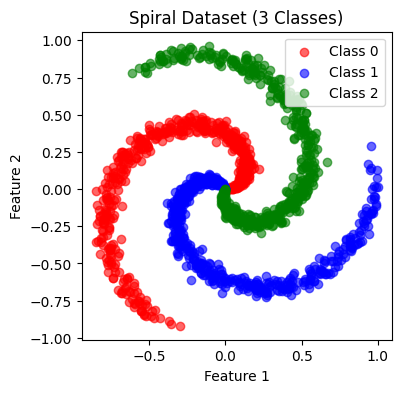

In [1]:
import torch
import matplotlib.pyplot as plt

def generate_spiral_data(n_samples=500, n_classes=3, noise=0.15):
    """生成螺旋数据集"""
    X = []
    y = []
    
    for i in range(n_classes):
        r = torch.linspace(0, 1, n_samples)
        theta = torch.linspace(i * 2 * torch.pi / n_classes, 
                              (i + 2) * 2 * torch.pi / n_classes, 
                              n_samples) + torch.randn(n_samples) * noise
        
        x1 = r * torch.cos(theta)
        x2 = r * torch.sin(theta)
        
        X.append(torch.stack([x1, x2], dim=1))
        y.append(torch.full((n_samples, 1), i))
    
    X = torch.cat(X, dim=0)
    y = torch.cat(y, dim=0).long()
    
    return X, y

# 生成数据
X, y = generate_spiral_data(n_samples=500, n_classes=3, noise=0.15)
print(f"数据形状: X={X.shape}, y={y.shape}")

# 可视化
plt.figure(figsize=(4, 4))
colors = ['red', 'blue', 'green']
for i in range(3):
    mask = (y.squeeze() == i)
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[i], label=f'Class {i}', alpha=0.6)
plt.legend()
plt.title('Spiral Dataset (3 Classes)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## MLP

In [ ]:
class MultiClassMLP:
    """多分类 MLP（手动实现）"""
    
    def __init__(self, input_size, hidden_sizes, output_size, activation='relu'):
        layer_sizes = [input_size] + hidden_sizes + [output_size]
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.params = {}
        self.grads = {}
        
        # Xavier 初始化
        for i in range(len(layer_sizes) - 1):
            fan_in = layer_sizes[i]
            fan_out = layer_sizes[i + 1]
            std = (2.0 / (fan_in + fan_out)) ** 0.5
            
            self.params[f'W{i}'] = torch.randn(fan_in, fan_out) * std
            self.params[f'b{i}'] = torch.zeros(fan_out)
    
    def forward(self, X):
        self.cache = {'a0': X}
        
        for i in range(len(self.layer_sizes) - 1):
            W = self.params[f'W{i}']
            b = self.params[f'b{i}']
            
            z = self.cache[f'a{i}'] @ W + b
            self.cache[f'z{i}'] = z
            
            if i < len(self.layer_sizes) - 2:
                if self.activation == 'relu':
                    a = torch.relu(z)
                else:
                    a = z
            else:
                a = z  # 输出层
            
            self.cache[f'a{i+1}'] = a
        
        return self.cache[f'a{len(self.layer_sizes)-1}']
    
    def softmax(self, x):
        exp_x = torch.exp(x - torch.max(x, dim=1, keepdim=True)[0])
        return exp_x / torch.sum(exp_x, dim=1, keepdim=True)
    
    def compute_loss(self, y_pred, y_true):
        probs = self.softmax(y_pred)
        n_samples = y_true.shape[0]
        n_classes = probs.shape[1]
        
        one_hot = torch.zeros(n_samples, n_classes)
        one_hot[range(n_samples), y_true.squeeze()] = 1
        
        loss = -torch.sum(one_hot * torch.log(probs + 1e-10)) / n_samples
        return loss
    
    def backward(self, X, y):
        n_samples = X.shape[0]
        
        z_last = self.cache[f'z{len(self.layer_sizes)-2}']
        probs = self.softmax(z_last)
        
        n_classes = probs.shape[1]
        one_hot = torch.zeros(n_samples, n_classes)
        one_hot[range(n_samples), y.squeeze()] = 1
        
        grad = probs - one_hot
        
        # 反向传播：从最后一层往前
        for i in range(len(self.layer_sizes) - 2, -1, -1):
            a_prev = self.cache[f'a{i}']
            z = self.cache[f'z{i}']  # 当前层的 z
            
            self.grads[f'W{i}'] = a_prev.T @ grad / n_samples
            self.grads[f'b{i}'] = torch.sum(grad, dim=0) / n_samples
            
            if i > 0:
                W = self.params[f'W{i}']
                grad = grad @ W.T  # 传播梯度到前一层
                
                # 应用激活函数导数（注意：这里用的是前一层的 z）
                z_prev = self.cache[f'z{i-1}']  # 前一层的 z
                if self.activation == 'relu':
                    grad = grad * (z_prev > 0).float()
    
    def update_sgd(self, lr):
        for key in self.params:
            self.params[key] -= lr * self.grads[key]
    
    def predict(self, X):
        y_pred = self.forward(X)
        probs = self.softmax(y_pred)
        return torch.argmax(probs, dim=1, keepdim=True)
    
    def accuracy(self, X, y):
        y_pred = self.predict(X)
        return (y_pred == y).float().mean()


# 训练函数
def train_mlp(model, X_train, y_train, X_test, y_test, epochs=200, lr=0.1):
    train_losses = []
    train_accs = []
    test_accs = []
    
    for epoch in range(epochs):
        y_pred = model.forward(X_train)
        loss = model.compute_loss(y_pred, y_train)
        train_losses.append(loss.item())
        
        model.backward(X_train, y_train)
        model.update_sgd(lr)
        
        train_acc = model.accuracy(X_train, y_train)
        test_acc = model.accuracy(X_test, y_test)
        train_accs.append(train_acc.item())
        test_accs.append(test_acc.item())
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, "
                  f"Train Acc: {train_acc.item():.4f}, Test Acc: {test_acc.item():.4f}")
    
    return train_losses, train_accs, test_accs


# 划分训练集和测试集
perm = torch.randperm(X.shape[0])
train_size = int(0.8 * X.shape[0])

X_train, X_test = X[perm[:train_size]], X[perm[train_size:]]
y_train, y_test = y[perm[:train_size]], y[perm[train_size:]]

print(f"训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")

# 创建模型: [2, 64, 32, 3]
print("创建 MLP 模型: 2 -> 64 -> 32 -> 3")
model = MultiClassMLP(input_size=2, hidden_sizes=[64, 32], output_size=3, activation='relu')

# 训练
print("\n开始训练...")
train_losses, train_accs, test_accs = train_mlp(
    model, X_train, y_train, X_test, y_test, 
    epochs=200, lr=0.1
)

# 最终准确率
final_train_acc = model.accuracy(X_train, y_train)
final_test_acc = model.accuracy(X_test, y_test)
print(f"\n最终准确率 - Train: {final_train_acc.item():.4f}, Test: {final_test_acc.item():.4f}")

NameError: name 'X' is not defined

### Draw results

In [ ]:
# 可视化决策边界
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    xx, yy = torch.meshgrid(torch.arange(x_min, x_max, h),
                            torch.arange(y_min, y_max, h), indexing='ij')
    
    grid = torch.stack([xx.flatten(), yy.flatten()], dim=1)
    Z = model.predict(grid).reshape(xx.shape)
    
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Spectral)
    
    colors = ['red', 'blue', 'green']
    for i in range(3):
        mask = (y.squeeze() == i)
        plt.scatter(X[mask, 0], X[mask, 1], c=colors[i], 
                   label=f'Class {i}', edgecolors='black', alpha=0.7)
    
    plt.legend()
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

plot_decision_boundary(model, X_test, y_test, "MLP Decision Boundary on Spiral Dataset")



# 学习曲线
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 3, 2)
plt.plot(train_accs, label='Train')
plt.plot(test_accs, label='Test')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(train_losses[-50:], label='Loss (last 50)')
plt.title('Training Loss (Last 50 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()